---
# K-Nearest Neighbors Algorithm and Applications
## Author: Ismail Syed
---

### Table of contents
* [Introduction](#Introduction)
* [Algorithm](#Algorithm)
* [Advantages](#Advantages)
* [Disadvantages](#Disadvantages)
* [KNN classifier Implementation](#Implementation)
* [Applications](#Applications)
* [Results and Impact](#Results)

## Introduction
KNN (K-Nearest Neighbors) is a supervised learning algorithm, which can be used for classification or regression tasks. For a given datapoint, it finds the 'k' closest datapoints/neighbors, and predicts the class (for classification) or average value (for regression).


---
## Algorithm
KNN operates on the principle that similar data will be clustered together. So, the label or value of a datapoint is predicted by the the labels or values of the datapoints around it.

__Step 1:__ Select an optimal value for K  
K represents the number of neighbors considered within each prediction.  

__Step 2:__ Pick a distance function  
Distance is calculated between data points in the dataset and target point. Different distance functions will yield different neighbors and thus different predictions

__Step 3:__ Find the Nearest Neighbors  
The k data points with the smallest distances from the target point are its nearest neighbors.  

__Step 4:__ Vote for Classification or Average for Regression  
In classification, we look at which category the K neighbors belong to, and pick the one that appears the most. This is called majority voting.  
In regression, we take the average of the values of the K neighbors. This average is the predicted value for the new point for the algorithm.

---

## Advantages
* KNN performs well when the data has clusters, or clear boundaries.
* Can easily change the distance function, to depending on the probelm
* No explicit training like other models - faster setup
* Performs computation only when we are looking for a prediction
* Underlying dataset can easily be extended by simply storing the new data - no need to spend time retraining

## Disadvantages
* Compuationally expensive predictions - have to test datapoint to all training datapoints
* Poor performance with high-dimensional data - all points tend to become more equally distanced
* Irrelevant features can distort the distances and neighbors
* Need to store entire dataset every time we are making a prediction
* Difficult to find optimal k
* Biased predictions on unbalanced data

## Implementation

#### Define the KNN class

In [44]:
class KNN(object):
    """
    A K-Nearest Neighbors (KNN) implementation.

    Parameters
    ---
    distance_function:
        A function taking two inputs (data points) and returning their distance.

    Raises
    ---
    TypeError:
        If distance_function is not callable.
    ValueError:
        If invalid value is entered
    """
    
    def __init__(self, distance_function):
        if not callable(distance_function):
            raise TypeError("distance_function must be a callable")
        self.dist_f = distance_function

    def get_neighbors(self, k, point, train_features, train_labels):
        """
        Find the k nearest neighbors to a datapoint

        Parameters
        ---
        k: integer
            The number of neighbors to return.
        point: array-like
            The input point for which we are to find neighbors.
        train_features: array-like
            Training feature vectors.
        train_labels: array-like
            Labels corresponding to training feature vectors.

        Returns
        ---
        list
            A list of the k nearest neighbors, each as a list - [feature_vector, label, distance].

        Raises
        ------
        ValueError
            If k is not a positive integer, or exceeds number of training examples.
        ValueError
            If train_features and train_labels are not of equal length.
        """
        if not isinstance(k, int) or k <= 0:
            raise ValueError("k must be a positive integer")
        if len(train_features) != len(train_labels):
            raise ValueError("train_features and train_labels must have the same length")
        if k > len(train_features):
            raise ValueError("k cannot be greater than the number of training examples")

        neighbors = []
        for p, label in zip(train_features, train_labels):
            try:
                d = self.dist_f(p, point)
            except Exception as e:
                raise ValueError(f"Error computing distance: {e}")
            neighbors.append([p, label, d])

        #Sort the neighbors based on the distance
        neighbors.sort(key=lambda x: x[-1])
        return neighbors[:k]

    def predict(self, point, train_features, train_labels, k):
        """
        Predict the label of a given data point.

        Parameters
        ----------
        point: array-like
            The data point to classify.
        train_features: array-like
            Feature vectors of training data.
        train_labels: array-like
            Labels for training data.
        k: int
            Number of nearest neighbors to consider.

        Returns
        -------
        Most common label among the k nearest neighbors.

        Raises
        ------
        ValueError
            If no neighbors are returned (e.g., empty training data).
        """
        neighbors = self.get_neighbors(k, point, train_features, train_labels)
        if not neighbors:
            raise ValueError("No neighbors found. Check your training data.")
        labels = [x[1] for x in neighbors]
        return max(labels, key=labels.count)


## Applications 

We are using the __wisconsin breast cancer dataset__.  
We will be predicting whether __radius__ and __texture__ (columns 2 and 3) can predict whether a tumor is __benign__ or __malignant__

#### Import Libraries that we will be using
__matplotlib__ for plotting  
__pandas__ and __numpy__ for data cleaning and manipulation  
__sklearn__ to split test and train data  

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

#### Import and clean the dataset

In [46]:
data = pd.read_csv("wisconsin_breast_cancer.data", header=None)
print(data.head())

y = np.array(data.iloc[: , 1])
y = y.reshape(-1,1)
y = np.where(y == 'M', 0, 1)

X = np.array(data.iloc[: , 2:4])
print(f"Example X value: {X[0]}")
print(f"Inputs matrix shape: {X.shape}")
print(f"Example y value: {y[0]}")
print(f"Outputs matrix shape: {y.shape}")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

         0  1      2      3       4       5        6        7       8   \
0    842302  M  17.99  10.38  122.80  1001.0  0.11840  0.27760  0.3001   
1    842517  M  20.57  17.77  132.90  1326.0  0.08474  0.07864  0.0869   
2  84300903  M  19.69  21.25  130.00  1203.0  0.10960  0.15990  0.1974   
3  84348301  M  11.42  20.38   77.58   386.1  0.14250  0.28390  0.2414   
4  84358402  M  20.29  14.34  135.10  1297.0  0.10030  0.13280  0.1980   

        9   ...     22     23      24      25      26      27      28      29  \
0  0.14710  ...  25.38  17.33  184.60  2019.0  0.1622  0.6656  0.7119  0.2654   
1  0.07017  ...  24.99  23.41  158.80  1956.0  0.1238  0.1866  0.2416  0.1860   
2  0.12790  ...  23.57  25.53  152.50  1709.0  0.1444  0.4245  0.4504  0.2430   
3  0.10520  ...  14.91  26.50   98.87   567.7  0.2098  0.8663  0.6869  0.2575   
4  0.10430  ...  22.54  16.67  152.20  1575.0  0.1374  0.2050  0.4000  0.1625   

       30       31  
0  0.4601  0.11890  
1  0.2750  0.08902  
2  0.

#### Define the distance and classification error function

In [47]:
def manhattan_distance(p1, p2):
    return np.sum(np.abs(p1 - p2))

def classification_error(test_features, test_labels, train_features, train_labels, model, k):
    error = 0
    for point, label in zip(test_features, test_labels):
        error += (label.item() != model.predict(point, train_features, train_labels, k))

    return error/len(test_features)

#### Usage of KNN and test the errors and classification

In [48]:
knn = KNN(manhattan_distance)
k1 = 7
k2 = 10
k3 = 100
k4 = y_test.shape[0]

correct_prediction = 0
incorrect_prediction = 0
for i in range(len(X_test)):
    y_pred = knn.predict(X_test[i], X_train, y_train, k1)
    if (y_pred == y_test[i]):
        correct_prediction += 1
    else:
        incorrect_prediction += 1
print(f"When k={k1}, there are {correct_prediction} correct predictions, and {incorrect_prediction} incorrect predictions")

When k=7, there are 102 correct predictions, and 12 incorrect predictions


## Results
Next, we will investigate how changing k changes the error rate.

Examples of how changing k changes the error
Error rate for k=7 is: 0.10526315789473684
Error rate for k=10 is: 0.12280701754385964
Error rate for k=100 is: 0.13157894736842105
Error rate for k=114 is: 0.14035087719298245


The k value of 28 gives the minimum error rate of 0.07894736842105263


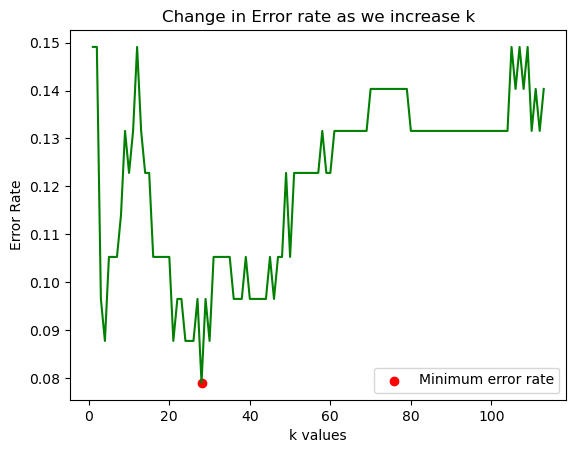

In [53]:
print("Examples of how changing k changes the error")
errors_k1 = classification_error(X_test, y_test, X_train, y_train, knn, k1)
errors_k2 = classification_error(X_test, y_test, X_train, y_train, knn, k2)
errors_k3 = classification_error(X_test, y_test, X_train, y_train, knn, k3)
errors_k4 = classification_error(X_test, y_test, X_train, y_train, knn, k4)

print(f"Error rate for k={k1} is: {errors_k1[0]}")
print(f"Error rate for k={k2} is: {errors_k2[0]}")
print(f"Error rate for k={k3} is: {errors_k3[0]}")
print(f"Error rate for k={k4} is: {errors_k4[0]}")

err_lst = []
min_k_err = (100, -1) #A tuple containing the minimum error amount and the corresponding k value
for k in range(1, y_test.shape[0]):
    ce = classification_error(X_test, y_test, X_train, y_train, knn, k)[0]
    if (ce < min_k_err[0]):
        min_k_err = (ce, k)
    err_lst.append(ce)

k_values = list(range(1, y_test.shape[0]))
plt.plot(k_values, err_lst, c = 'g')
plt.xlabel('k values')
plt.ylabel('Error Rate')
plt.title('Change in Error rate as we increase k')
plt.scatter(min_k_err[1], min_k_err[0], color='red', label = 'Minimum error rate')
plt.legend()
print(f'\n\nThe k value of {min_k_err[1]} gives the minimum error rate of {min_k_err[0]}')
plt.show()


This experiment seems to show that the best value of k - according to the graph - is at 28.
Next, we will display how the algorithm splits the regions of space differently for different values of k

#### Plotting Decision Boundaries alongside test features

In [50]:
def plot_decision_boundary(model, X_train, y_train, X_test, y_test, k, h=0.7):
    #define the plotting area (+2 and -2 for some padding)
    f1_min, f1_max = X_train[:, 0].min() - 2, X_train[:, 0].max() + 2
    f2_min, f2_max = X_train[:, 1].min() - 2, X_train[:, 1].max() + 2

    #Create a grid of x, y points to cover the whole area
    xx, yy = np.meshgrid(np.arange(f1_min, f1_max, h),
                         np.arange(f2_min, f2_max, h))
    Z = np.array([
        model.predict(np.array([x, y]), X_train, y_train, k)
        for x, y in zip(xx.flatten(), yy.flatten())
    ])
    
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bone')

    y_flatten = y_test.flatten()
    plt.scatter(X_test[y_flatten == 0, 0], 
                X_test[y_flatten == 0, 1], 
                label='Malignant', edgecolors='r')
    
    plt.scatter(X_test[y_flatten == 1, 0], 
                X_test[y_flatten == 1, 1], 
                label='Benign', edgecolors='g')
    
    plt.title(f"KNN Decision Boundary (k={k})")
    plt.xlabel("Radius")
    plt.ylabel("Texture")
    plt.legend()
    plt.show()

#### Impact of k
##### (Running this may take a lot of time)
Below, we show how the KNN model changes the split of the dataset, and plot onto this split the test dataset, so measure how performance is different with different values of k - remember that k=28 gives the most optimal split amongst all the values of k

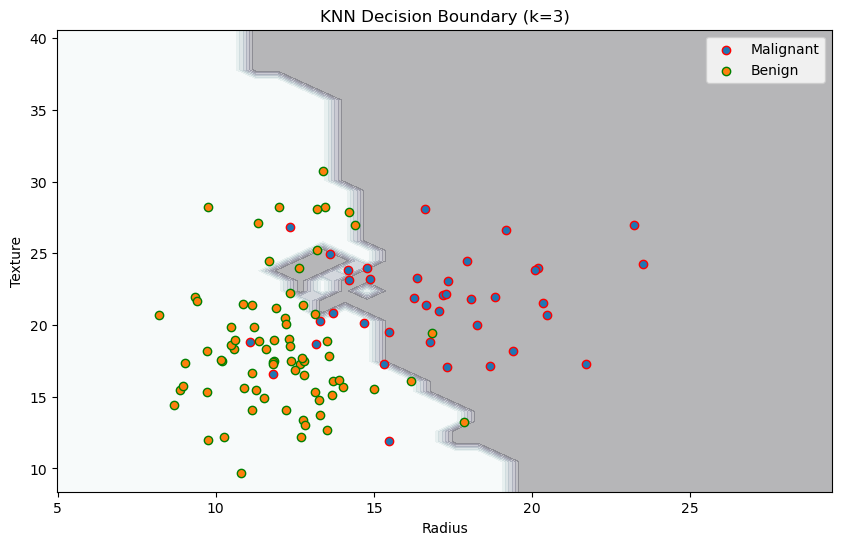

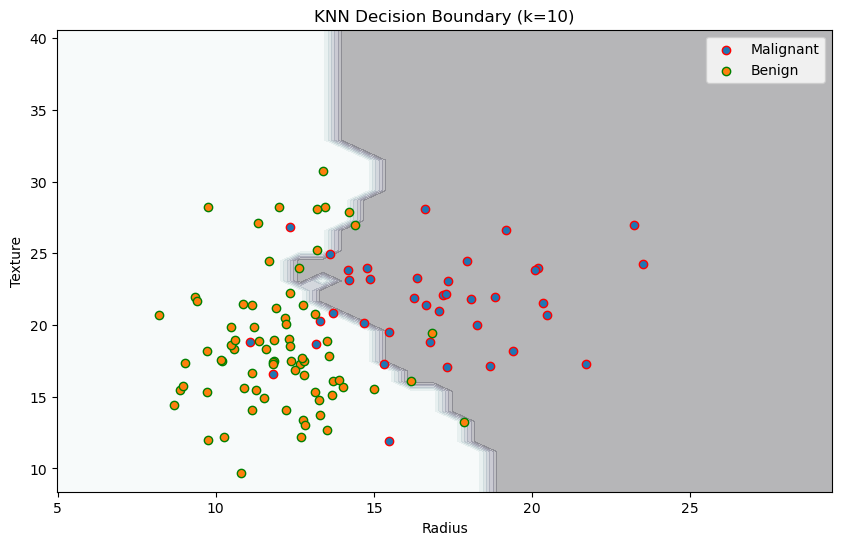

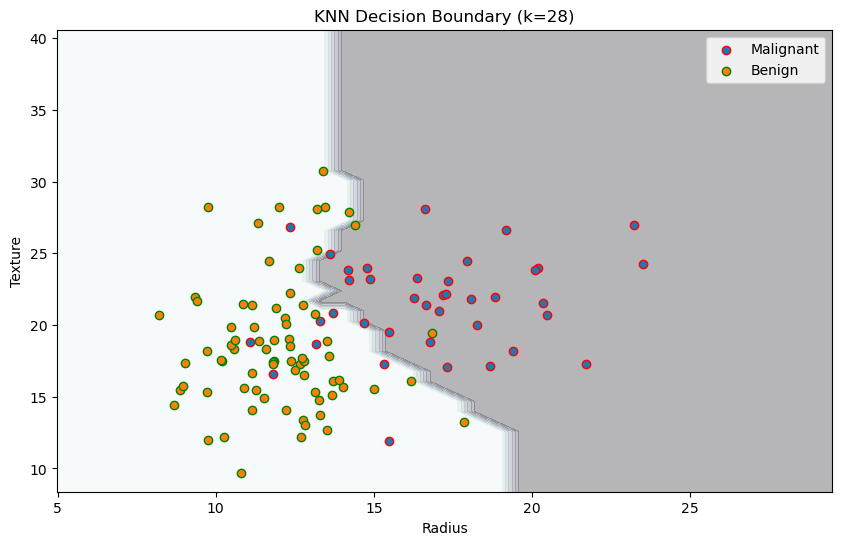

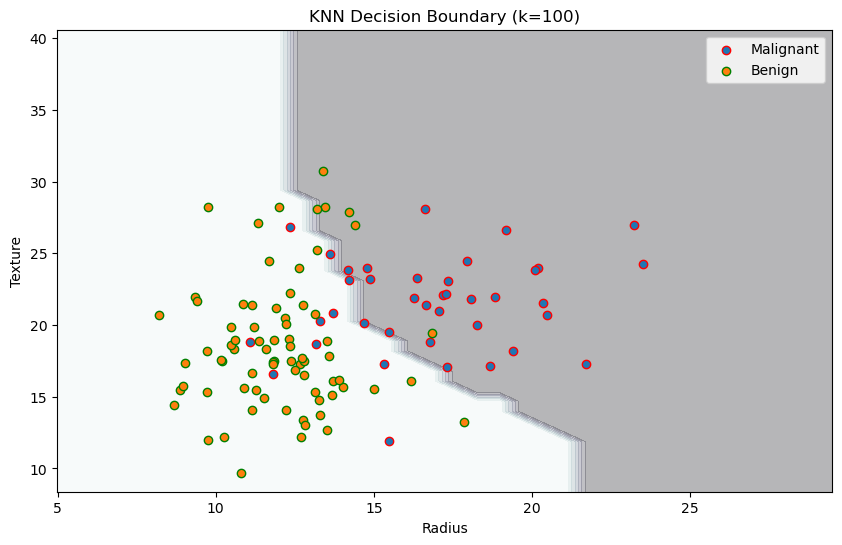

In [51]:
plot_decision_boundary(knn, X_train, y_train, X_test, y_test, k=3)
plot_decision_boundary(knn, X_train, y_train, X_test, y_test, k=10)
plot_decision_boundary(knn, X_train, y_train, X_test, y_test, k=28)
plot_decision_boundary(knn, X_train, y_train, X_test, y_test, k=100)